# Flam R&D Assignment – Parametric Curve Parameter Estimation

## Objective

The goal is to estimate the unknown parameters θ, M, and X
of the given parametric curve using the provided xy data.

The parameters are estimated by minimizing the L1 distance
between the given data points and the predicted curve.

## Parametric Equations

The given parametric equations are:

\[
x(t)=t\cos(\theta)-e^{M|t|}\sin(0.3t)\sin(\theta)+X
\]

\[
y(t)=42+t\sin(\theta)+e^{M|t|}\sin(0.3t)\cos(\theta)
\]

The unknown parameters are:

- θ: \(0 < \theta < 50^\circ\)
- M: \(-0.05 < M < 0.05\)
- X: \(0 < X < 100\)

The parameter \(t\) lies in:

\[
6 < t < 60
\]

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import differential_evolution

## Dataset

The provided CSV contains 1500 x-y points belonging to the
given parametric curve.

The points are sorted by x so that they follow the curve order.
Then uniformly spaced t values are assigned over the given range.

In [38]:
df=pd.read_csv("xy_name.csv")
df = df.sort_values("x").reset_index(drop=True)

print(df.head())
print(df.shape)

           x          y
0  59.657204  46.032295
1  59.732390  46.070210
2  59.798930  46.103054
3  59.839375  46.122692
4  59.841995  46.123955
(1500, 2)


In [39]:
x_actual=df["x"].values
y_actual=df["y"].values

## Parametric Curve Function

The mathematical equations are implemented as a Python function.
The angle θ is converted from degrees to radians because NumPy's
trigonometric functions use radians.

In [40]:
def curve(t,theta,M,X):
    
    theta = np.radians(theta)
    x=(t*np.cos(theta)-np.exp(M*np.abs(t))*np.sin(0.3*t)*np.sin(theta)+X)
    y = (
        42
        + t * np.sin(theta)
        + np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.cos(theta)
    )
    return x,y

In [41]:
t=np.linspace(6,60,len(x_actual))
x,y=curve(t,theta=25,M=0.1,X=30)

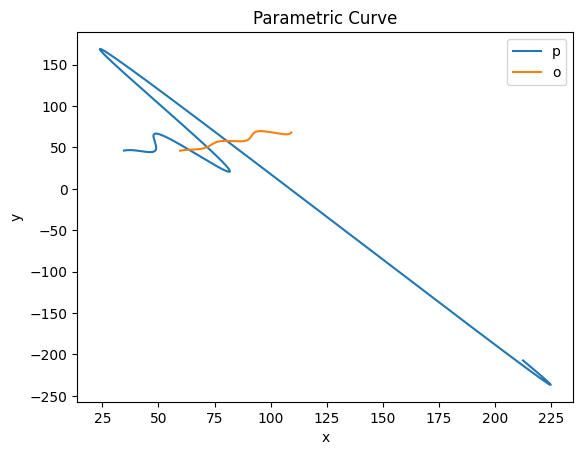

In [42]:
plt.plot(x, y,label='p')
plt.plot(x_actual,y_actual,label='o')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Parametric Curve")
plt.legend()

plt.show()

## Objective Function

To determine how well a particular set of parameters fits the
given data, the L1 distance is calculated.

For predicted points \((x_i^{pred}, y_i^{pred})\) and actual points
\((x_i, y_i)\):

\[
L1 = \sum_i
\left(
|x_i-x_i^{pred}| +
|y_i-y_i^{pred}|
\right)
\]

The optimizer attempts to minimize this value.

In [43]:
def objective(params):
    theta,M,X=params
    x_pred,y_pred=curve(t,theta,M,X)
    error=np.sum(np.abs(x_actual-x_pred)+np.abs(y_actual-y_pred))
    return error

## Parameter Optimization

Differential Evolution is used to search for the values of θ, M,
and X that minimize the L1 objective function.

The parameter bounds are:

- θ: 0 to 50 degrees
- M: -0.05 to 0.05
- X: 0 to 100

In [44]:
bounds=[
    (0,50),
    (-0.05,0.05),
    (0,100)
]
result = differential_evolution(
    objective,
    bounds=bounds,
    maxiter=2000,
    popsize=20,
    tol=1e-10,
    polish=True,
    seed=42
)

In [45]:
print(f"theta={result.x[0]},M={result.x[1]},X={result.x[2]}")

print(result.fun)

theta=30.043636280842,M=0.02999054536457818,X=55.01552025735891
453.4369002770826


In [46]:
theta_opt,M_opt,X_opt=result.x
x_pred,y_pred=curve(t,theta_opt,M_opt,X_opt)

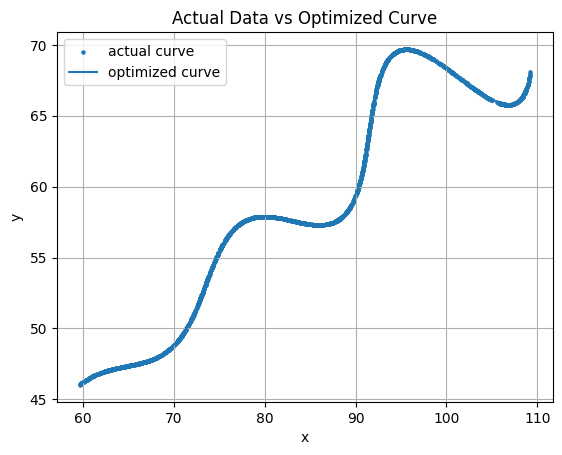

In [47]:
plt.scatter(x_actual,y_actual,s=5,label='actual curve')
plt.plot(x_pred,y_pred,label='optimized curve')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Actual Data vs Optimized Curve")
plt.legend()
plt.grid()

plt.show()

## Optimized Parameters

In [48]:
print(f"theta = {theta_opt:.6f} degrees")
print(f"M     = {M_opt:.6f}")
print(f"X     = {X_opt:.6f}")
print(f"L1    = {result.fun:.6f}")

theta = 30.043636 degrees
M     = 0.029991
X     = 55.015520
L1    = 453.436900


In [52]:
error_optimized = objective(result.x)

error_round = objective([30, 0.03, 55])

print("Optimized:", error_optimized)
print("Round:", error_round)

Optimized: 453.4369002770826
Round: 457.04520235973985


In [53]:
mean_error=result.fun/len(x_actual)
print("Total L1 error:", result.fun)
print("Mean L1 error per point:", mean_error)

Total L1 error: 453.4369002770826
Mean L1 error per point: 0.3022912668513884


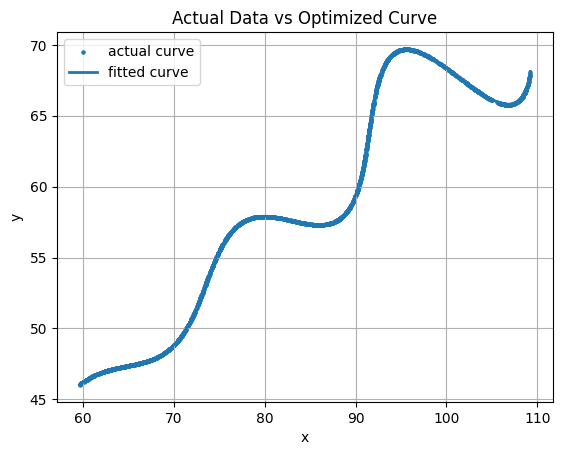

In [55]:
theta_opt,M_opt,X_opt=result.x
x_pred,y_pred=curve(t,theta_opt,M_opt,X_opt)
plt.scatter(x_actual,y_actual,s=5,label='actual curve')
plt.plot(x_pred,y_pred,linewidth=2,label='fitted curve')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Actual Data vs Optimized Curve")
plt.legend()
plt.grid()

plt.show()

## Conclusion

The unknown parameters of the given parametric curve were estimated
using Differential Evolution by minimizing the L1 distance between
the provided data points and the predicted curve.

The estimated parameters are:

- θ ≈ 30.043636°
- M ≈ 0.029991
- X ≈ 55.015520

The final visualization shows that the fitted curve closely follows
the provided data points, indicating a good parameter fit.

## Desmos Verification

The optimized parameters obtained using Differential Evolution were
verified independently in Desmos. The resulting parametric curve closely
matches the fitted curve obtained in Python.

- θ = 30.043636°
- M = 0.029991
- X = 55.015520

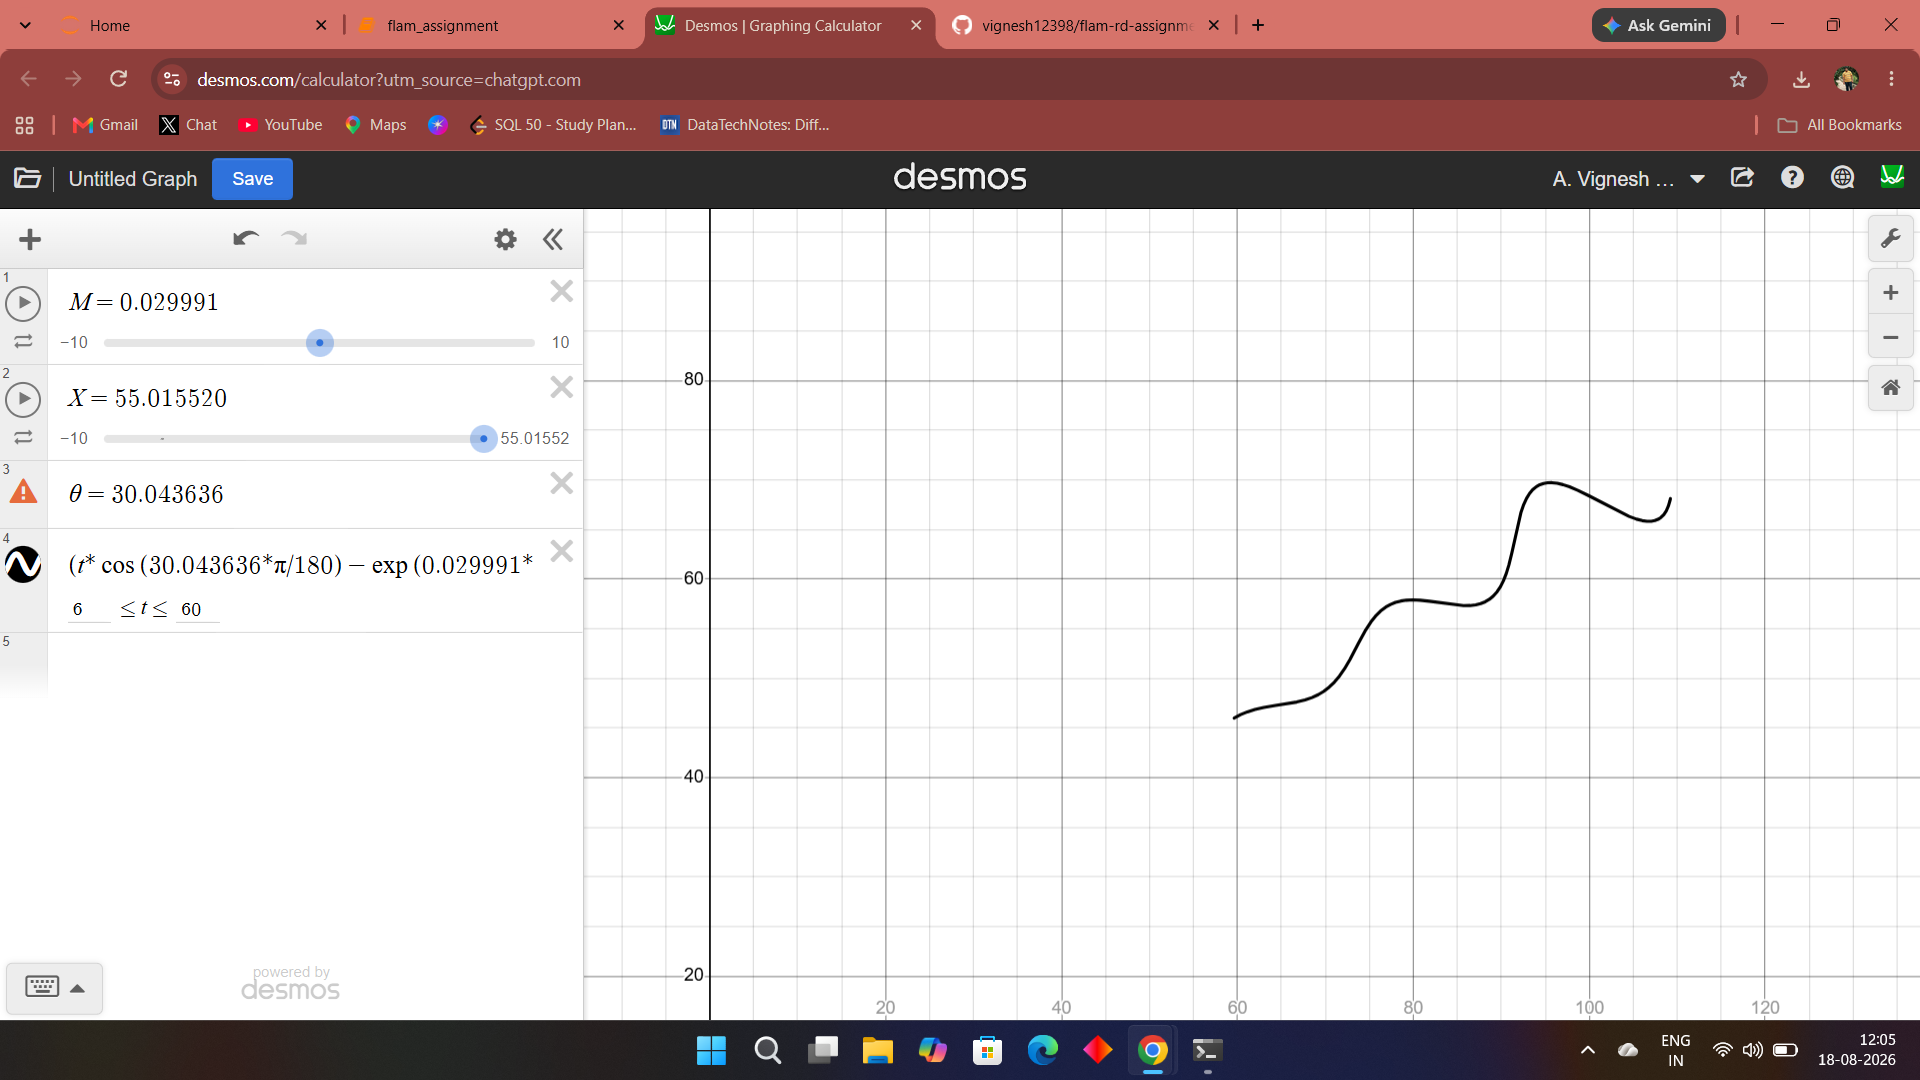